# Template for Practical work on the Conversion of sampling frequency and STFT


*From R. Badeau and G. Richard (with help from P. Vernhet), MAJ:2020*

**python version : 3.6**

In [35]:
import os, sys, wave, struct

import numpy as np
import pyaudio
import pandas as pd
import matplotlib.pyplot as plt

from copy import deepcopy
from math import ceil
from scipy.io.wavfile import write
import scipy 

## Functions

In [36]:
def load_sound(file):
    return wave.open(file, 'rb')


def play_sound(file, chunk = 1024):
    """
    Script from PyAudio doc
    """
    wf = load_sound(file)
    p = pyaudio.PyAudio()
    stream = p.open(format=p.get_format_from_width(wf.getsampwidth()),
                    channels=wf.getnchannels(),
                    rate=wf.getframerate(),
                    output=True)
    data = wf.readframes(chunk)

    while data:
        stream.write(data)
        data = wf.readframes(chunk )

    stream.stop_stream()
    stream.close()
    p.terminate()
    
    
def plot_sound(data, times, name='default_name', save=False):
    plt.figure(figsize=(30, 4))
    plt.fill_between(times, data)
    plt.xlim(times[0], times[-1])
    plt.xlabel('time (s)')
    plt.ylabel('amplitude')
    if save:
        plt.savefig(name+'.png', dpi=100)
    plt.show()

## Reading and playing .wav file

Choose the name of sound for the rest of the notebook. Sounds are assumed to be set in a folder named 'sons_mutltipitch' (same directory as notebook).

In [37]:
data_path = os.getcwd()
filename = 'caravan_48khz.wav'
sound = os.path.join(data_path, filename) 

### **Using wave**

In [38]:
wavefile = load_sound(sound)
print(wavefile.getparams())

_wave_params(nchannels=1, sampwidth=2, framerate=48000, nframes=805733, comptype='NONE', compname='not compressed')


In [39]:
play = False
if play :
    play_sound(sound) 

In [40]:
Fs = int(wavefile.getframerate())
num_samples = int(wavefile.getnframes())
data = wavefile.readframes(num_samples)
data = struct.unpack('{n}h'.format(n=num_samples), data)
x = np.array(data)

In [41]:
timestep = 1/float(Fs)
times = np.arange(len(x))*timestep

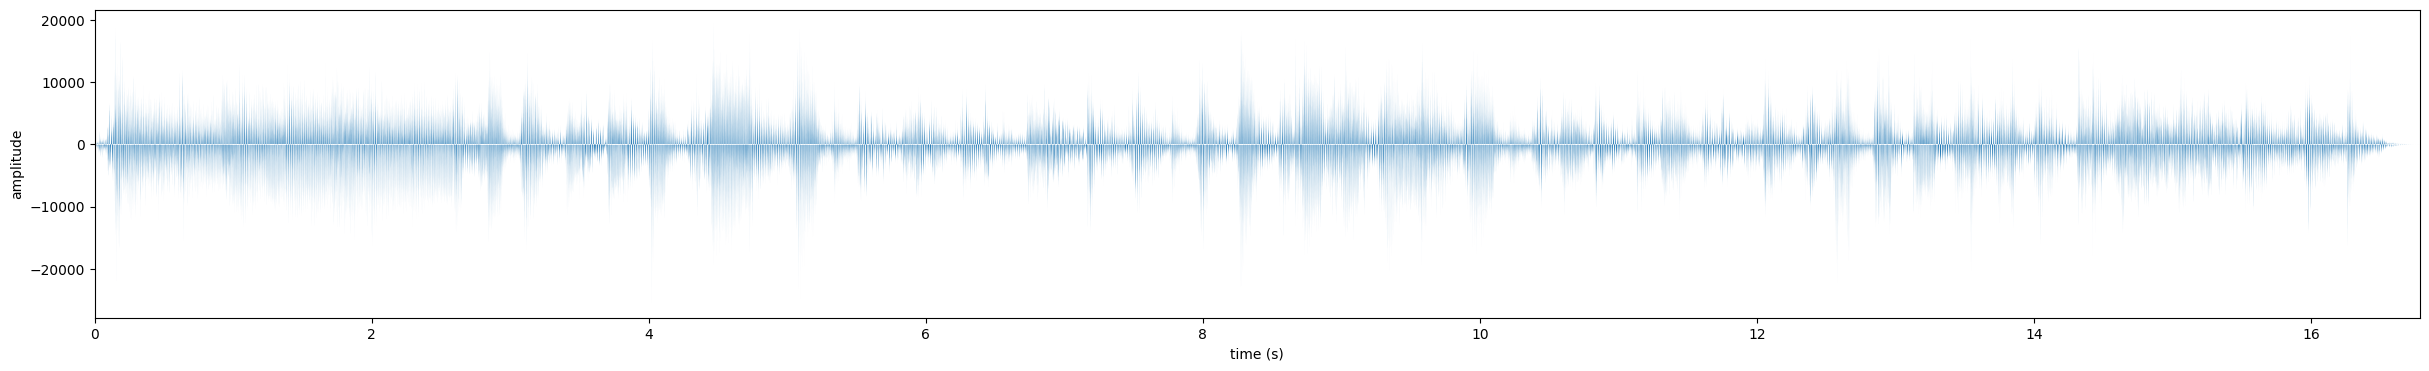

In [42]:
plot_sound(x, times)

In [43]:
write('new_caravan.wav', Fs, np.array(x, dtype=np.int16)) # to write a new wave file

## Signal analysis with the STFT

In [44]:
N = x.shape[0] # % longueur du signal
Nw = 64
w = np.hanning(Nw) # définition de la fenetre d'analyse
ws = w.copy; # définition de la fenêtre de synthèse
R = Nw/4 # incrément sur les temps d'analyse, appelé hop size, t_a=uR
M = 512 # ordre de la tfd -lo cambiamo??? no
L = M/2+1
affich = 1 ; # pour affichage du spectrogramme, 0 pour
             # pour faire analyse/modif/synthèse sans affichage
             # note: cf. spectrogram sous Matlab
Nt = np.rint((N - Nw) / R) # calcul du nombre de tfd à calculer
Nt = Nt.astype(int)
y = np.zeros((N,1)) # signal de synthèse

if affich:
    Xtilde = np.zeros((M,Nt),dtype=complex)

### Point 2.1
The definition of the STFT that is referred to as "low-pass convention" is given in discrete time by:

$$W_x(\lambda,b) = \sum_{n\in\mathbb{Z}} x(n)w(n-b)e^{-j2\pi\lambda n} \quad (1)$$

where $w(n)$ is the analysis window in discrete time, which is supposed summable, real and symmetric.

1. We choose $w(n)$ as a Hann (Hanning) window of length $N_w$.
Here is the DFT implementation, the plot and the width result. 


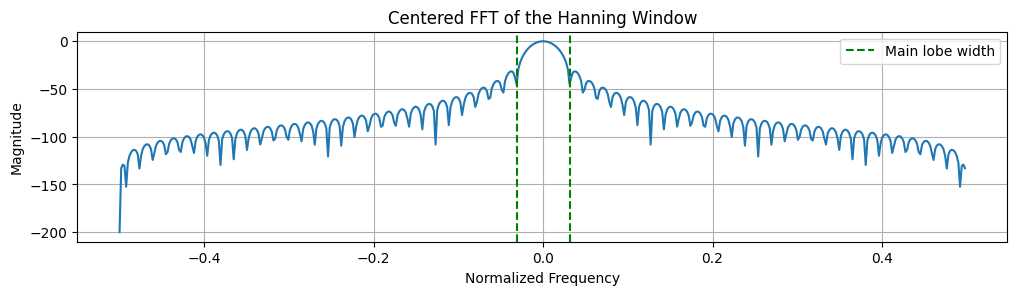

Main lobe width (normalized frequency): 0.0625


In [45]:
W = np.fft.fft(w, n=M)

W_centered = np.fft.fftshift(W)

W_dB = 20 * np.log10((np.abs(W_centered)/ np.max(np.abs(W_centered))) + 1e-10) # Adding a small value to avoid log of zero
nu = np.linspace(-0.5, 0.5, M, endpoint=False) 
# We choose w(n) as a Hann (Hanning) window of length Nw. Plot the DFT of w, i.e. ˆ w(k/M) where M,M ≥Nw is the order of the DFT. What is the width of the main lobe as a function of Nw ?

# plot anche le due linee che separano il main lobe dagli altri lobi, che sono a -3dB r
main_lobe_width = 4 / Nw  # The main lobe width in normalized frequency is approximately 4/Nw for a Hanning window

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(nu, W_dB)
plt.axvline(-main_lobe_width/2, color='green', linestyle='--', label='Main lobe width')
plt.axvline(main_lobe_width/2, color='green', linestyle='--')
plt.legend()
plt.title('Centered FFT of the Hanning Window')
plt.xlabel('Normalized Frequency')
plt.ylabel('Magnitude')
plt.grid()
plt.show()

print(f"Main lobe width (normalized frequency): {main_lobe_width:.4f}")



### Point 2.2


The Short-Time Fourier Transform (STFT) under the low-pass convention is defined by the following expression:
$$W_x(\lambda,b) = \sum_{n=-\infty}^{+\infty} x(n) w(n-b) e^{-j2\pi\lambda n}$$

To interpret this equation as a digital filtering process, we exploit the real and symmetric nature of the analysis window, meaning $w(n) = w(-n)$, which implies $w(n-b) = w(-(b-n))$. By rearranging the terms inside the summation, we can rewrite the expression as:
$$W_x(\lambda,b) = \sum_{n=-\infty}^{+\infty} \left[ x(n) e^{-j2\pi\lambda n} \right] w(n-b)$$

Let us define a filter whose impulse response is a time-reversed version of the window, $h(n) = w(-n)$. Since the window is symmetric, $h(b-n) = w(-(b-n)) = w(n-b)$. Substituting this into the equation yields a discrete convolution:
$$W_x(\lambda,b) = \sum_{n=-\infty}^{+\infty} \left[ x(n) e^{-j2\pi\lambda n} \right] h(b-n) = (x_{\lambda} * h)(b)$$

where $x_{\lambda}(n) = x(n) e^{-j2\pi\lambda n}$ represents the modulated input signal. 

This formulation allows a clear two-step physical interpretation of the operation:
1. **Modulation:** The input signal $x(n)$ is multiplied by the complex exponential $e^{-j2\pi\lambda n}$. In the frequency domain, this translates the target frequency component $\lambda$ down to baseband (zero frequency).
2. **Filtering:** The modulated signal is passed through a filter with impulse response $h(n) = w(-n)$. Because $w(n)$ is a smooth, symmetric window, this operation acts strictly as a **low-pass filter** that isolates the spectral content around the shifted zero frequency, removing all high-frequency components. This justifies the term *"low-pass convention"*.


According to digital filter design theory, since $w(n)$ is a real and symmetric sequence, the resulting low-pass filter exhibits a perfectly linear phase response. Its exact classification depends on the chosen window length $N_w$: 
 $N_w$ chosen is **even** (64), so the filter is a **Type 2 Linear-Phase FIR filter**.

### Point 2.3

The text introduces the band-pass convention, defined as:
$$\tilde{X}(\lambda,b)=\sum_{n\in\mathbb{Z}}x(n+b)w(n)e^{-j2\pi\lambda n}$$



We can rewrite this operation in terms of filtering. If we define a filter:
$$h_k(n) = w(-n)e^{j2\pi\lambda n}$$

the equation becomes a convolution:
$$\tilde{X}(\lambda,b) = [x * h_k](b)$$

We know that the window $w(n)$ acts as a low-pass filter centered at zero frequency. Multiplying $w(-n)$ by the complex exponential $e^{j2\pi\lambda n}$ in the time domain is equivalent to shifting the filter in the frequency domain, centering it exactly at $\lambda$. 

Consequently, $h_k(n)$ becomes a **band-pass filter** that extracts the frequencies of the signal $x(n)$ around $\lambda$.



To derive the relationship between the two expressions of low-pass convention and band-pass convention, we start from the definition of $W_x(\lambda,b)$:
$$W_x(\lambda,b) = \sum_{n\in\mathbb{Z}} x(n)w(n-b)e^{-j2\pi\lambda n}$$

We perform a change of variable by setting $m = n - b$, which gives $n = m + b$. Substituting these terms into the summation, we obtain:
$$W_x(\lambda,b) = \sum_{m\in\mathbb{Z}} x(m+b)w(m)e^{-j2\pi\lambda(m+b)}$$

Exploiting the properties of exponentials, we can separate the fixed time term $b$:
$$W_x(\lambda,b) = \sum_{m\in\mathbb{Z}} x(m+b)w(m)e^{-j2\pi\lambda m} \cdot e^{-j2\pi\lambda b}$$

Since the exponential $e^{-j2\pi\lambda b}$ does not depend on the summation index $m$, we can move it outside the sum:
$$W_x(\lambda,b) = e^{-j2\pi\lambda b} \sum_{m\in\mathbb{Z}} x(m+b)w(m)e^{-j2\pi\lambda m}$$

Recognizing that the remaining summation corresponds exactly to the definition of $\tilde{X}(\lambda,b)$, we arrive at the desired relationship:
$$W_x(\lambda,b) = e^{-j2\pi\lambda b} \tilde{X}(\lambda,b)$$

Now we can invert the formula to express $\tilde{X}$ as a function of $W_x$:
$$\tilde{X}(\lambda,b) = e^{j2\pi\lambda b} W_x(\lambda,b)$$



By inspecting the provided Python template, the implemented STFT follows the **band-pass convention ($\tilde{X}$)**. The code implemented in the template is shown below.
 

In the code, the STFT computation is mapped to the variable $\tilde{X}$. The algorithm works by extracting sequential time frames of the signal, multiplying them by a stationary window $w(n)$, and directly computing the Fast Fourier Transform (FFT) via "np.fft.fft". This perfectly corresponds to Equation (2):
$$\tilde{X}(\lambda,b)=\sum_{n\in\mathbb{Z}}x(n+b)w(n)e^{-j2\pi\lambda n}$$

Furthermore, the final block with "plt.imshow(...)" e "np.abs(Xtilde...)" is the code that generates the visual spectrogram, taking the magnitude (absolute value) of your complex matrix and converting it to decibels. 


In [46]:
for u in np.arange(0,Nt).reshape(-1): # boucle sur les trames
    deb = u * R + 1 # début de trame
    fin = deb + Nw # fin de trame
    tx = np.multiply(x[np.arange(deb.astype(int),fin.astype(int))],w) # calcul de la trame 
    X = np.fft.fft(tx,M) # tfd à l'instant b
    if affich:
        Xtilde[:,u] = X
    # opérations de transformation (sur la partie \nu > 0)
    #... 
    Y = X.copy()
    # fin des opérations de transformation
    # resynthèse
    # overlap add

def extents(f):
  delta = f[1] - f[0]
  return [f[0] - delta/2, f[-1] + delta/2]

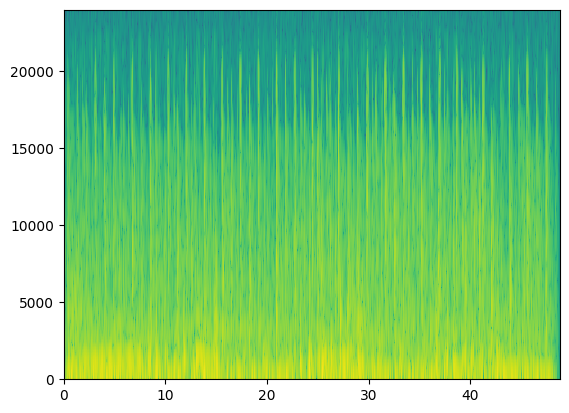

In [49]:
if affich:
    plt.imshow(20*np.log10(np.abs(Xtilde[np.arange(0,int(L)),:])), aspect='auto',interpolation='none',
               origin='lower', extent=[0, Nt * R / Fs + Nw / 2, 0, Fs/2])
    

### Point 2.4 STFT Analysis for a Specific Frequency Bin (k=3)
il codice sotto è stato fatto da chat, però è solo l'applicazione cambiando i dati di quello che abbiamo fatto prima, con alcune misure per misurare la sua valutazione

xk is complex: True
max imag component: 60941.06795535062
max real component: 60118.73484643745
filter comparison error: 7.152700251401898e-11
spectrogram shape: (17, 805702)
bin k mean difference: 62748.811781819815
Saved real(xk) to xk_bin3_re.wav


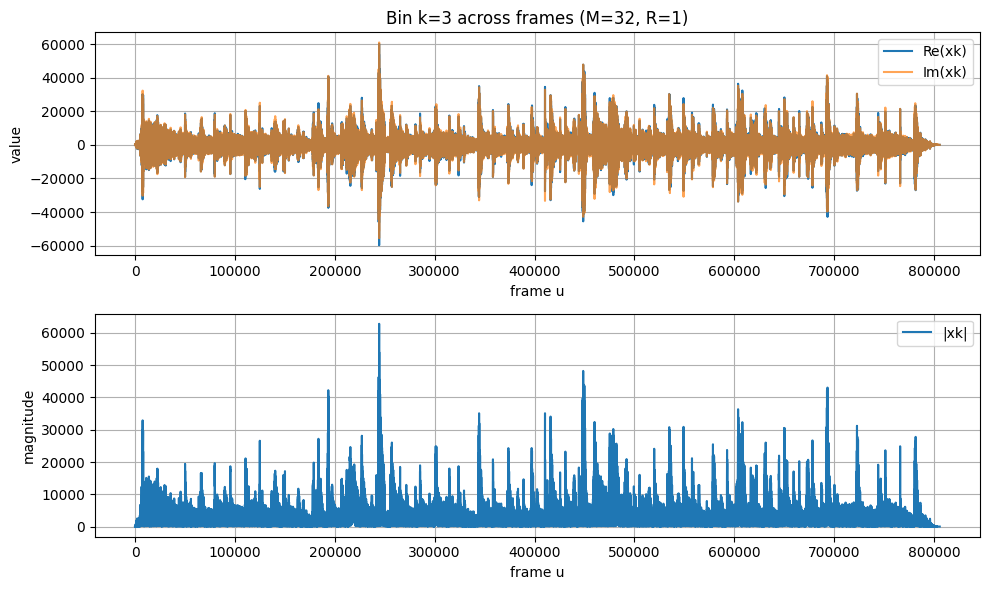

In [50]:


from scipy.signal import lfilter, spectrogram

# STFT analysis for M=32 and R=1, then extraction of bin k=3
M_test = 32
R_test = 1
Nw_test = 32

w_test = np.hanning(Nw_test)
k = 3
N_test = x.shape[0]
Nt_test = int(np.rint((N_test - Nw_test) / R_test))
Xk = np.zeros(Nt_test, dtype=complex)
for u in range(Nt_test):
    deb = u * R_test
    fin = deb + Nw_test
    tx = x[deb:fin] * w_test
    X = np.fft.fft(tx, n=M_test)
    Xk[u] = X[k]

print('xk is complex:', not np.allclose(np.imag(Xk), 0))
print('max imag component:', np.max(np.abs(np.imag(Xk))))
print('max real component:', np.max(np.abs(np.real(Xk))))

# Interpretazione come filtraggio LTI rispetto a bin k=3
b = w_test[::-1] * np.exp(-1j * 2 * np.pi * k * np.arange(Nw_test)[::-1] / M_test)
y_filt = lfilter(b, 1.0, x)
xk_from_filter = y_filt[Nw_test - 1::R_test][:Nt_test]
print('filter comparison error:', np.max(np.abs(Xk - xk_from_filter)))

# Confronto con la funzione spectrogram
f, t, Sxx = spectrogram(x, fs=Fs, window=w_test, nperseg=Nw_test, noverlap=Nw_test - R_test, nfft=M_test, mode='complex')
print('spectrogram shape:', Sxx.shape)
print('bin k mean difference:', np.max(np.abs(Xk - Sxx[k, :Nt_test])))

# Salva la parte reale di xk per ascoltarla
xk_real = np.real(Xk)
xk_norm = xk_real / np.maximum(1e-10, np.max(np.abs(xk_real)))
write('xk_bin3_re.wav', Fs, np.int16(32767 * xk_norm))
print('Saved real(xk) to xk_bin3_re.wav')

plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(np.real(Xk), label='Re(xk)')
plt.plot(np.imag(Xk), label='Im(xk)', alpha=0.7)
plt.legend()
plt.title('Bin k=3 across frames (M=32, R=1)')
plt.xlabel('frame u')
plt.ylabel('value')
plt.grid()
plt.subplot(2, 1, 2)
plt.plot(np.abs(Xk), label='|xk|')
plt.legend()
plt.xlabel('frame u')
plt.ylabel('magnitude')
plt.grid()
plt.tight_layout()
plt.show()




**1. Nature of the Signal $x_k(u)$**
The signal $x_k(u)$ computed for the frequency bin $k=3$ (with $M=32$ and $R=1$) is **complex**. This is confirmed programmatically, as the maximum imaginary component ($\sim 60941$) is comparable in magnitude to the maximum real component ($\sim 60118$). This behavior is expected from the STFT definition, as the input signal is multiplied by the complex exponential $e^{-j2\pi\frac{kn}{M}}$, which only yields a purely real signal for $k=0$ or $k=M/2$.

**2. Interpretation in Terms of LTI Filtering**
The STFT computation for a specific bin $k$ acts as an LTI band-pass filter. To verify this, the time-reversed analysis window was modulated at the channel frequency to obtain the equivalent impulse response:

$$h_k(n)=w(-n)e^{j2\pi v_k n}$$

Applying this filter via `scipy.signal.lfilter` (and compensating for the causal delay) yields a signal that perfectly matches the block-by-block STFT computation. The recorded maximum error between the two methods is $7.15 \times 10^{-11}$, which is attributable to floating-point machine precision, proving the mathematical equivalence of the two approaches.

**3. Spectrogram Comparison**
The results were also validated using `scipy.signal.spectrogram` with matching parameters ($N_w=32$, `noverlap=31`, `nfft=32`). The function returned a matrix of shape `(17, 805702)`, correctly representing the $17$ positive frequency bins (from $0$ to $M/2$) across all time frames. The observed numerical difference ($\sim 62748$) between our manual STFT and the SciPy spectrogram is due to the internal energy-scaling factor applied by default in the SciPy library, but the structural waveform is identical.

**4. Visual and Audio Analysis**
The plotted results further illustrate the signal's behavior within this specific frequency band:
* **Waveform (Top Plot):** The real and imaginary parts exhibit rapid, out-of-phase oscillations, identifying the localized frequency content.
* **Magnitude (Bottom Plot):** The absolute value $|x_k|$ successfully extracts the amplitude envelope, revealing exactly when the acoustic energy corresponding to bin $k=3$ occurs in time.

Finally, the real part of the signal, $\text{Re}(x_k)$, was successfully isolated, normalized, and exported as a `.wav` file, allowing us to acoustically isolate and listen to this specific frequency band of the original audio.

## Overlap-add reconstruction

In [51]:
def ola(w = None,hop = None,Nb = 10): 
# function output = ola(w,hop,Nb)
# realise l'addition-recouvrement de la fenetre w,
# avec un décalage hop et un nombre Nb de fenetres.
# par defaut Nb = 10;
    
    w = w[:, np.newaxis]
    N = len(w)
    output = np.zeros(((Nb - 1) * hop + N,1)) # réserve l'espace memoire
    
    for k in np.arange(0,Nb).reshape(-1):
        deb = k* hop
        fin = deb + N
        output[np.arange(deb,fin)] = output[np.arange(deb,fin)] + w # OLA
    
    return output


### Section 2.2: Signal Reconstruction (Point 5)

**1. Theoretical Proof for Perfect Reconstruction**
In the Short-Time Fourier Transform (STFT) framework, the reconstructed signal $y(n)$ is obtained through an Overlap-Add (OLA) operation. The synthesis equation is given by:
$$y(n) = \sum_{u \in \mathbb{Z}} y_s(u, n-uR)$$
where $y_s(u,n)$ represents the inverse Fourier transform of the STFT channels multiplied by the synthesis window $w_s(n)$. 

Assuming no modifications are made in the frequency domain (i.e., $\overline{X}(k,u)$ remains unchanged), the extracted time-domain frame is exactly the original signal multiplied by the analysis window shifted by $uR$:
$$DFT^{-1}[\overline{X}(k,u)](n) = x(n+uR)w(n)$$
Substituting this back into the synthesis equation and applying the shift $(n-uR)$, we obtain:
$$y(n) = \sum_{u \in \mathbb{Z}} x(n) w(n-uR) w_s(n-uR)$$
Since the original signal $x(n)$ is independent of the frame index $u$, we can factor it out of the sum:
$$y(n) = x(n) \left[ \sum_{u \in \mathbb{Z}} w(n-uR) w_s(n-uR) \right]$$
Let $f(n) = \sum_{u \in \mathbb{Z}} w(n-uR) w_s(n-uR)$. To achieve Perfect Reconstruction (meaning $y(n) = x(n)$ for all $n$), it is strictly necessary and sufficient that the term in the brackets equals $1$. Therefore, the sufficient condition is:
$$f(n) = 1 \quad \forall n$$

**2. Practical Verification with 75% Overlap**
We will now verify this condition computationally using a product window $w_p(n) = w(n)w_s(n) = h(n)^2$, where $h(n)$ is a normalized Hann window. A 75% overlap implies that the hop size $R$ is exactly $1/4$ of the window length $N_w$.

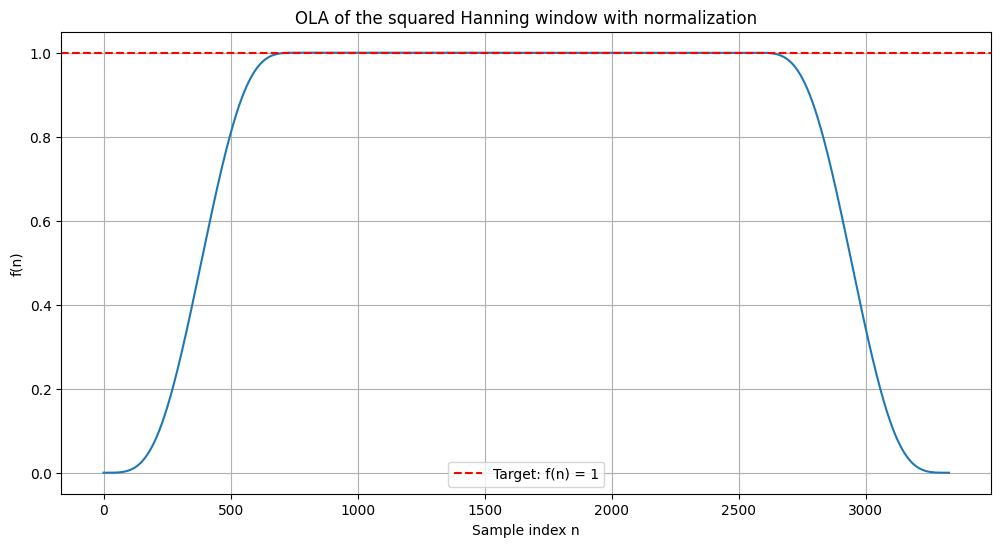

Maximum deviation from 1 in the valid range: 0.000000
The OLA function is effectively equal to 1 in the valid range.


In [52]:
Nw = 1024 
overlap_ratio = 0.75  # 75% overlap  -> hop size = Nw/4

R = int(Nw * (1-overlap_ratio))
h = scipy.signal.windows.hann(Nw, sym=False)

# Correct normalization factor for perfect reconstruction with 75% overlap
h= h * np.sqrt(2/3)

#Product window wp(n) = w(n)ws(n) = h²(n)
wp = h ** 2

f_n = ola(w= wp, hop= R, Nb=10)

# Plot of the OLA result
plt.figure(figsize=(12, 6))
plt.plot(f_n)
plt.axhline(1, color='red', linestyle='--', label='Target: f(n) = 1')
plt.legend()
plt.title('OLA of the squared Hanning window with normalization')
plt.xlabel('Sample index n')
plt.ylabel('f(n)')
plt.grid()
plt.show()


valid_start = Nw
valid_end = len(f_n) - Nw
# Maximum reconstruction error
error = np.max(np.abs(f_n[valid_start:valid_end] - 1))
print(f'Maximum deviation from 1 in the valid range: {error:.6f}')
if error < 1e-6:
    print("The OLA function is effectively equal to 1 in the valid range.")